#import necessary library for analysis and visualization

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Inject the data

In [62]:
df1 = pd.read_csv("titanic.csv")

In [63]:
df1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,3,"Braund, Mr. Owen Harris",male,22,1,no,A/5 21171,7.25,NaN,S
1,2,1,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,no,PC 17599,71.2833,C85,C
2,3,1,third,"Heikkinen, Miss. Laina",female,26,no,no,STON/O2. 3101282,7.925,NaN,S
3,4,1,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,no,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,no,373450,8.05,NaN,S


# Always copy the dataset into new dataframe , and perform over there

In [64]:
df=df1.copy()

# Clean the Data

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   PassengerId  891 non-null    int64 
 1   Survived     891 non-null    object
 2   Pclass       891 non-null    object
 3   Name         891 non-null    object
 4   Sex          884 non-null    object
 5   Age          714 non-null    object
 6   SibSp        891 non-null    object
 7   Parch        891 non-null    object
 8   Ticket       891 non-null    object
 9   Fare         891 non-null    object
 10  Cabin        204 non-null    object
 11  Embarked     889 non-null    object
dtypes: int64(1), object(11)
memory usage: 83.7+ KB


In [66]:
# Insights >> total 891 entries are there and in Age, Cabin , embarked columns we have missing values .
# And Rather than PassengerId column all others columns has objest datatype item

In [67]:
# removing unnecessary column
df.drop(columns=["PassengerId","Name"], inplace= True)

In [68]:
# Which fearures should be in numerical , try to convert into numerical from categorical like Pclass , Age etc

In [69]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,no,3,male,22,1,no,A/5 21171,7.25,NaN,S
1,1,first,female,38,1,no,PC 17599,71.2833,C85,C
2,1,third,female,26,no,no,STON/O2. 3101282,7.925,NaN,S
3,1,first,female,35,1,no,113803,53.1,C123,S
4,0,3,male,35,0,no,373450,8.05,NaN,S


In [70]:
df.Survived.unique()

array(['no', '1', '0', 'yes'], dtype=object)

In [71]:
df["Survived"]=df["Survived"].map({"no": 0 , "yes": 1 , "0": 0 , "1": 1})

In [72]:
df.Survived.unique()

array([0, 1])

In [73]:
df.Pclass.unique()

array(['3', 'first', 'third', '1', 'second', '2'], dtype=object)

In [74]:
df["Pclass"] = df["Pclass"] .replace({"first": 1, "second": 2 , "third" : 3 } )

In [75]:
df.Pclass.unique()

array(['3', 1, 3, '1', 2, '2'], dtype=object)

In [76]:
df.Pclass = df.Pclass.astype(int)

In [77]:
df.Age.unique()

array(['22', '38', '26', '35', nan, '54', '2', '27', '14', '4', '58',
       '[20]', '"39"', '""', '55', '31', '34', '15', '28', '8', '19',
       '40', '66', '42', '21', '18', '3', '7', '49', '29', '65', '28.5',
       '5', '11', '45', '17', '32', '16', '25', '0.83', '30', '33', '23',
       '24', '20', '46', '59', '71', '37', '47', '14.5', "70.5'", '32.5',
       '12', '9', '36.5', '51', '55.5', '40.5', '44', '1', '61', '56',
       '50', '36', '45.5', '20.5', '62', '41', '52', '63', '23.5', '0.92',
       '43', '60', '39', '10', '64', '13', '48', '0.75', '53', '57', '80',
       '70', '24.5', '6', '0.67', '30.5', '0.42', '34.5', '74', '"32\''],
      dtype=object)

In [78]:
df["Age"] = df["Age"].astype(str).str.replace(r"[\[\]'\" ]", "", regex=True)

In [79]:
df.Age.unique()

array(['22', '38', '26', '35', 'nan', '54', '2', '27', '14', '4', '58',
       '20', '39', '', '55', '31', '34', '15', '28', '8', '19', '40',
       '66', '42', '21', '18', '3', '7', '49', '29', '65', '28.5', '5',
       '11', '45', '17', '32', '16', '25', '0.83', '30', '33', '23', '24',
       '46', '59', '71', '37', '47', '14.5', '70.5', '32.5', '12', '9',
       '36.5', '51', '55.5', '40.5', '44', '1', '61', '56', '50', '36',
       '45.5', '20.5', '62', '41', '52', '63', '23.5', '0.92', '43', '60',
       '10', '64', '13', '48', '0.75', '53', '57', '80', '70', '24.5',
       '6', '0.67', '30.5', '0.42', '34.5', '74'], dtype=object)

In [80]:
df.Age = pd.to_numeric(df.Age, errors = "coerce" )

In [81]:
df.Age.dtype

dtype('float64')

In [82]:
df.SibSp.unique()

array(['1', 'no', '0', '3', '4', 'three', '2', '5', '8'], dtype=object)

In [83]:
df["SibSp"] = df["SibSp"].astype(str).replace(r"[^0-9.]", "", regex = True)


In [84]:
df.SibSp.unique()

array(['1', '', '0', '3', '4', '2', '5', '8'], dtype=object)

In [85]:
df["SibSp"] = pd.to_numeric(df["SibSp"], errors="coerce")

In [86]:
df.Parch.unique()

array(['no', '1', '2', '0', '5', '3', '4', '6'], dtype=object)

In [87]:
df.Parch= df.Parch.replace(r"[no]", np.nan , regex= True)

In [88]:
df.Parch.unique()

array([nan, '1', '2', '0', '5', '3', '4', '6'], dtype=object)

In [89]:
df.Parch= pd.to_numeric(df.Parch , errors = "coerce")

In [90]:
df.Fare = df.Fare.astype(str).replace(r"^0-9.","", regex =True)

In [91]:
df.Fare = pd.to_numeric(df.Fare , errors = "coerce")

In [92]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin', 'Embarked'],
      dtype='object')

In [93]:
# Drop the Ticket and Cabin column also
df.drop(columns= ["Ticket", "Cabin"] , inplace =True)

# Fill missing value

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       884 non-null    object 
 3   Age       713 non-null    float64
 4   SibSp     889 non-null    float64
 5   Parch     884 non-null    float64
 6   Fare      887 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(4), int64(2), object(2)
memory usage: 55.8+ KB


In [95]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,7
Age,178
SibSp,2
Parch,7
Fare,4
Embarked,2


In [96]:
# we can see in Sex, Age, Sibsp,Parch,Fare, Embarked columns we have the missing value .
columns = ["Sex","Age","SibSp","Parch","Fare","Embarked"]
for i in columns :
  if( df[i].dtype == "float64") or (df[i].dtype == "int64") :
    df[i].fillna(df[i].median() , inplace= True)
  else :
    df[i].fillna(df[i].mode()[0] , inplace = True)



In [97]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


# Now Data is clean , Try to get some analyse with visuals

In [98]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

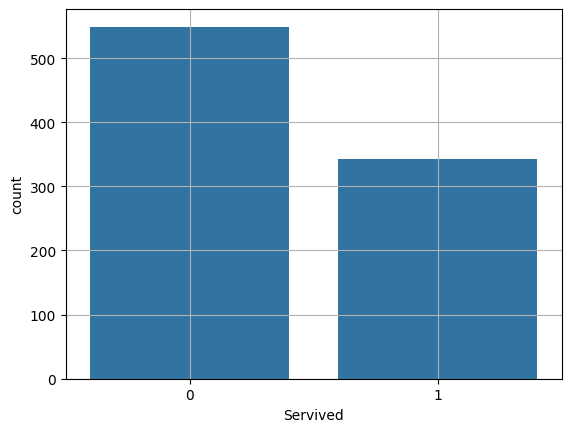

In [99]:
# univariate analysis
plt.figure()
sns.countplot(x ="Survived" , data = df )
plt.xlabel( "Servived")
plt.ylabel("count")
plt.grid()
plt.show()

In [100]:
# insights >> more people are died

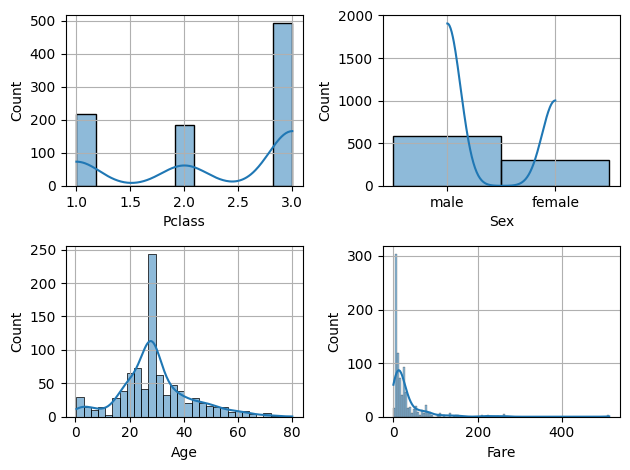

In [101]:
columns =['Pclass', 'Sex', 'Age', "Fare"]
j = 1
for i in columns :
  plt.subplot(2,2,j)
  sns.histplot(x= i , data = df , kde = True)
  plt.ylabel("Count")
  j+=1
  plt.tight_layout()
  plt.grid()
plt.tight_layout()

In [102]:
# insights >> In the ship , 3rd class passangers are more , male are more and middle age person are more and from our 4th graph mean Fare
# graph we can also see _ there are many person with the chepest price , and the graph is highly righ skewed (means outlier maybe there)

In [103]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

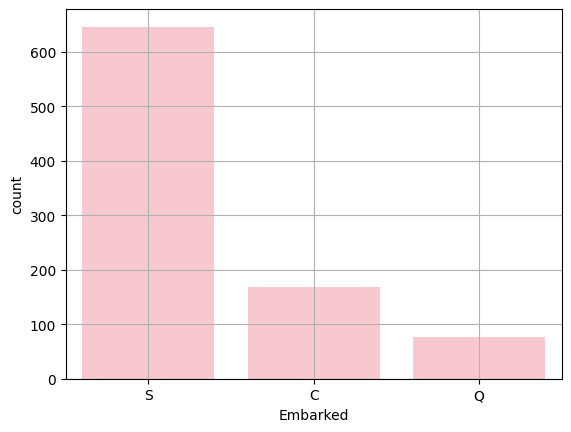

In [104]:
plt.figure()
sns.countplot(x ="Embarked" , data = df , color= "pink" )
plt.xlabel( "Embarked")
plt.ylabel("count")
plt.grid()
plt.show()

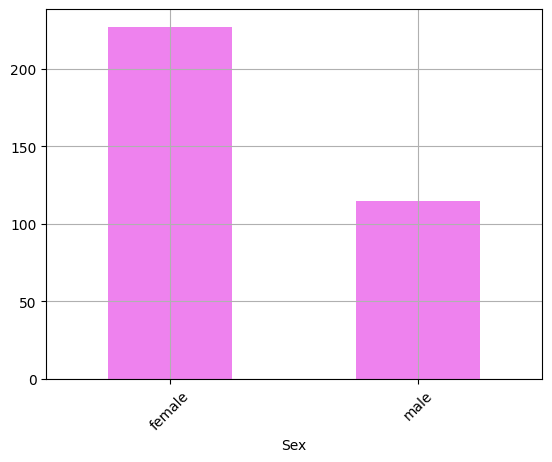

,count
Sex,
male,584
female,307


In [105]:
# Bivariate analysis :

a = df.groupby("Sex")["Survived"].sum()
a.plot(kind= "bar" , color= "violet")
plt.xticks(rotation=45)
plt.grid()
plt.show()
df["Sex"].value_counts()

In [106]:
# insights >> Though male's count  were more than female count in ship but , female survived more

,count
Pclass,
3,491
1,217
2,183


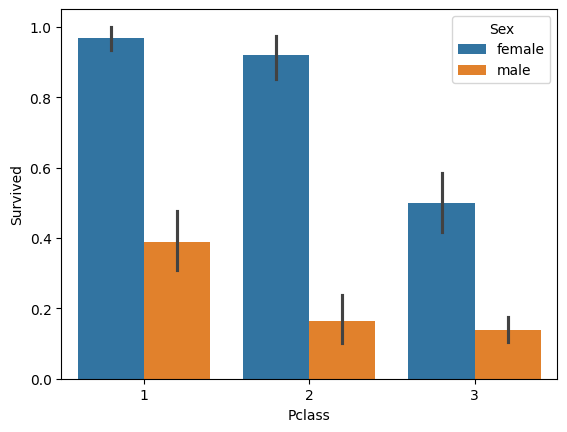

In [107]:
sns.barplot(x="Pclass",y = "Survived", data = df, hue = "Sex")
df["Pclass"].value_counts()

In [108]:
# Though there are less number of 1st class passenger but , they survived more , and among them female survived more .
# For all Pclass female survived more


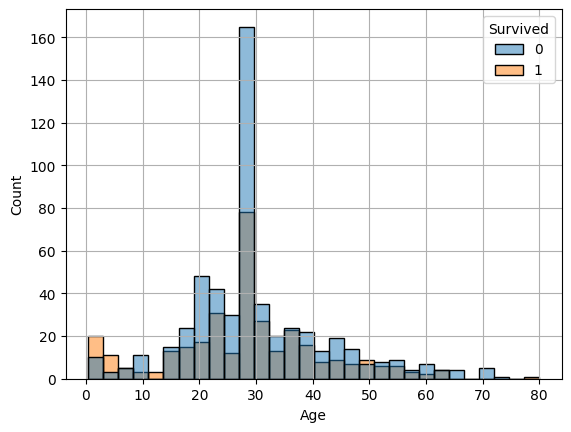

In [109]:
plt.figure()
sns.histplot(x= "Age",data = df ,hue ="Survived")
plt.grid()
plt.show()

In [110]:
# insights >> survived person belongs to every age , but , more numbers children were died

In [111]:
# to do multivariate analysis we first need to convert all the feature into numeric
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    float64
 5   Parch     891 non-null    float64
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(4), int64(2), object(2)
memory usage: 55.8+ KB


In [112]:
# for Sex and Embarked column , we have to convert these into numeric >> This is known as Encoding .
# for these columns (Sex and Embarked) , there are no order thats why we will perform OneHotEncoding with pandas function
df = pd.get_dummies(df , columns = ["Sex" ,"Embarked"], drop_first = True)

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    float64
 4   Parch       891 non-null    float64
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(4), int64(2)
memory usage: 44.5 KB


In [114]:
df.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

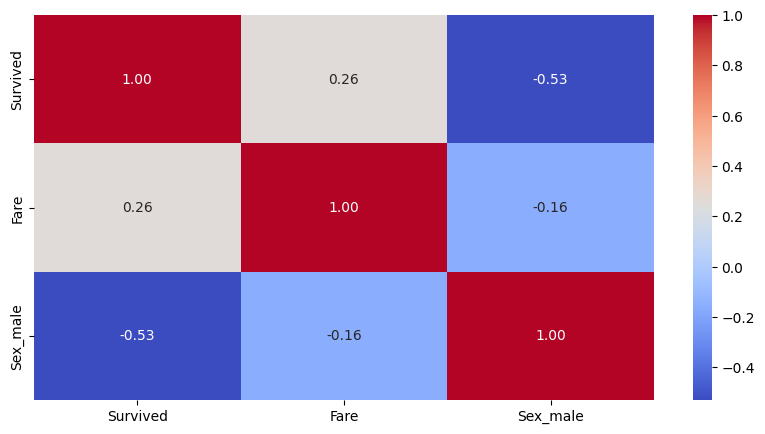

In [115]:
 # With heat map
 coorelation = df[['Survived','Fare','Sex_male']].corr()
 plt.figure(figsize =(10,5))
 sns.heatmap(coorelation,annot = True , cmap = "coolwarm", fmt=".2f" )
 plt.show()

# EDA

In [116]:
# treat with outlier

In [117]:
cols = ['Age', 'SibSp', 'Parch', 'Fare']

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lf = q1 - 1.5 * iqr
    uf = q3 + 1.5 * iqr
    df[col] = df[col].clip(lf, uf)

In [118]:
# After treat with outlier , lets draw the box plot , as from boxplot we can see the outlier

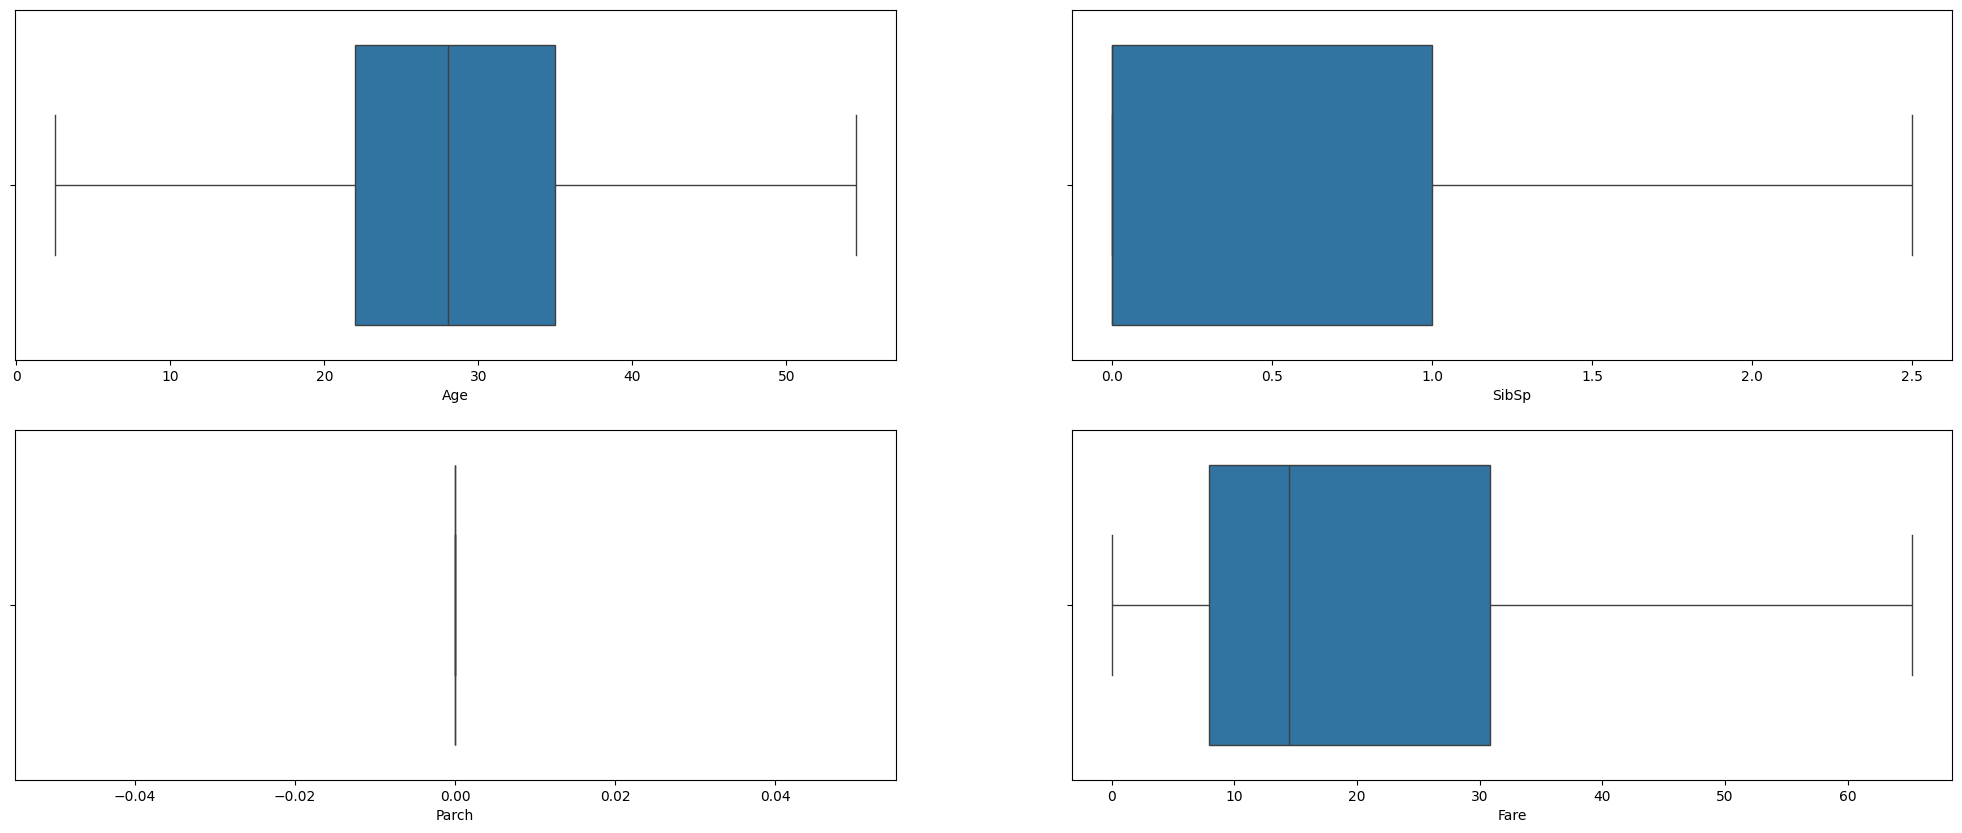

In [119]:
a = ['Age', 'SibSp', 'Parch', 'Fare']
plt.figure(figsize=(25,10))
for i in range(len(a)):
  plt.subplot(2,2,i+1)
  sns.boxplot(x=a[i], data = df)

In [120]:
df.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [121]:
# feature engineering >> create new column / feature from existing fetures
df["Family size"] = df.Parch + df.SibSp + 1

In [122]:
# Always chesk before model traing , if there are any null or categorical data / object feature
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Age          891 non-null    float64
 3   SibSp        891 non-null    float64
 4   Parch        891 non-null    float64
 5   Fare         891 non-null    float64
 6   Sex_male     891 non-null    bool   
 7   Embarked_Q   891 non-null    bool   
 8   Embarked_S   891 non-null    bool   
 9   Family size  891 non-null    float64
dtypes: bool(3), float64(5), int64(2)
memory usage: 51.5 KB


# Model training and evaluation

In [123]:
# Here i'm going to perform the randomforest classification model , because it help to find out the best feature
# import the require library

In [124]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [125]:
# Split features & target
X = df.drop('Survived', axis=1)
y = df['Survived']


In [126]:
# train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [127]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [128]:
# Random Forest Model
rf = RandomForestClassifier(n_estimators=200,max_depth=None,random_state=42)

In [129]:
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [130]:
# Predictions
y_pred = rf.predict(X_test_scaled)

In [131]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8379888268156425

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87       105
           1       0.84      0.76      0.79        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179


Confusion Matrix:
 [[94 11]
 [18 56]]


In [132]:
# Feature Importance
feature_importance = pd.Series(rf.feature_importances_,index=X.columns).sort_values(ascending=False)

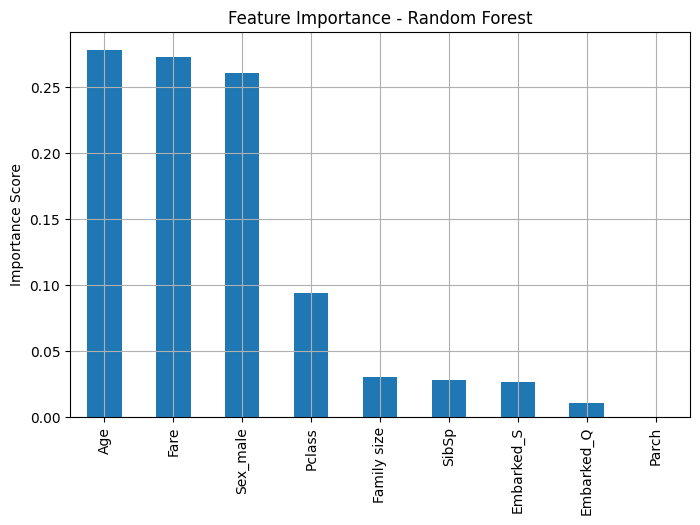

In [133]:
plt.figure(figsize=(8, 5))
feature_importance.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.grid()
plt.show()